<a href="https://colab.research.google.com/github/tomonari-masada/course2026-intro2ml/blob/main/09_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ロジスティック回帰
* 線形回帰を少し変えれば、２値分類に使うこともできるようになる。
* 線形モデルの出力を、シグモイド関数と呼ばれる関数で$[0,1]$の範囲の値へ変換する。
* 目的変数の値が0のときは、0に近い値が出力されるように、また・・・
* 目的変数の値が1のときは、1に近い値が出力されるように、モデルの学習を行う。

## 標準シグモイド関数
$$ \sigma(x) = \frac{1}{1 + e^{- x}} $$
* 単に「シグモイド関数」と言うときは、大体この標準シグモイド関数のことを意味する。

### 準備

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

### シグモイド関数のグラフを描く
* シグモイド関数の値（縦軸の値）が0から1の範囲に収まっていることを確認してみる。

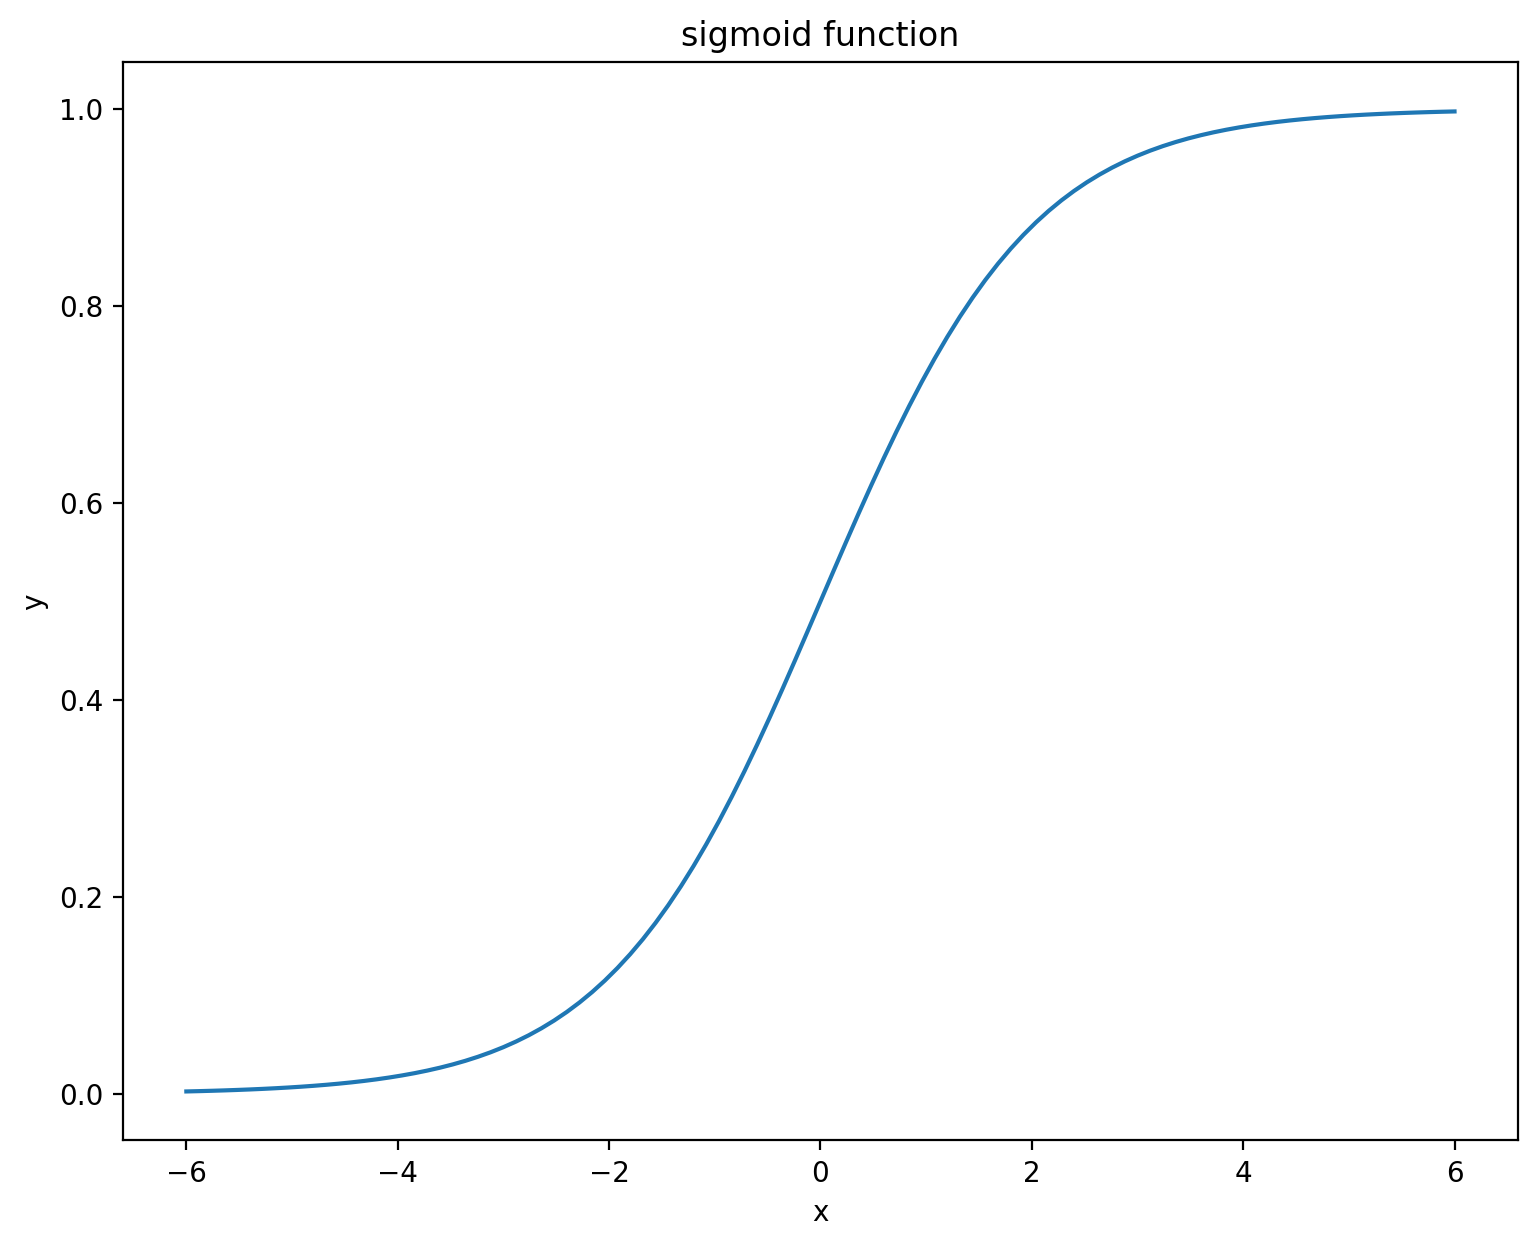

In [3]:
x = np.linspace(-6, 6, 101)
y = 1 / (1 + np.exp( - x))
fig = plt.figure(figsize=(9,7))
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('sigmoid function')
plt.show()

## toy dataでロジスティック回帰の使い方を把握

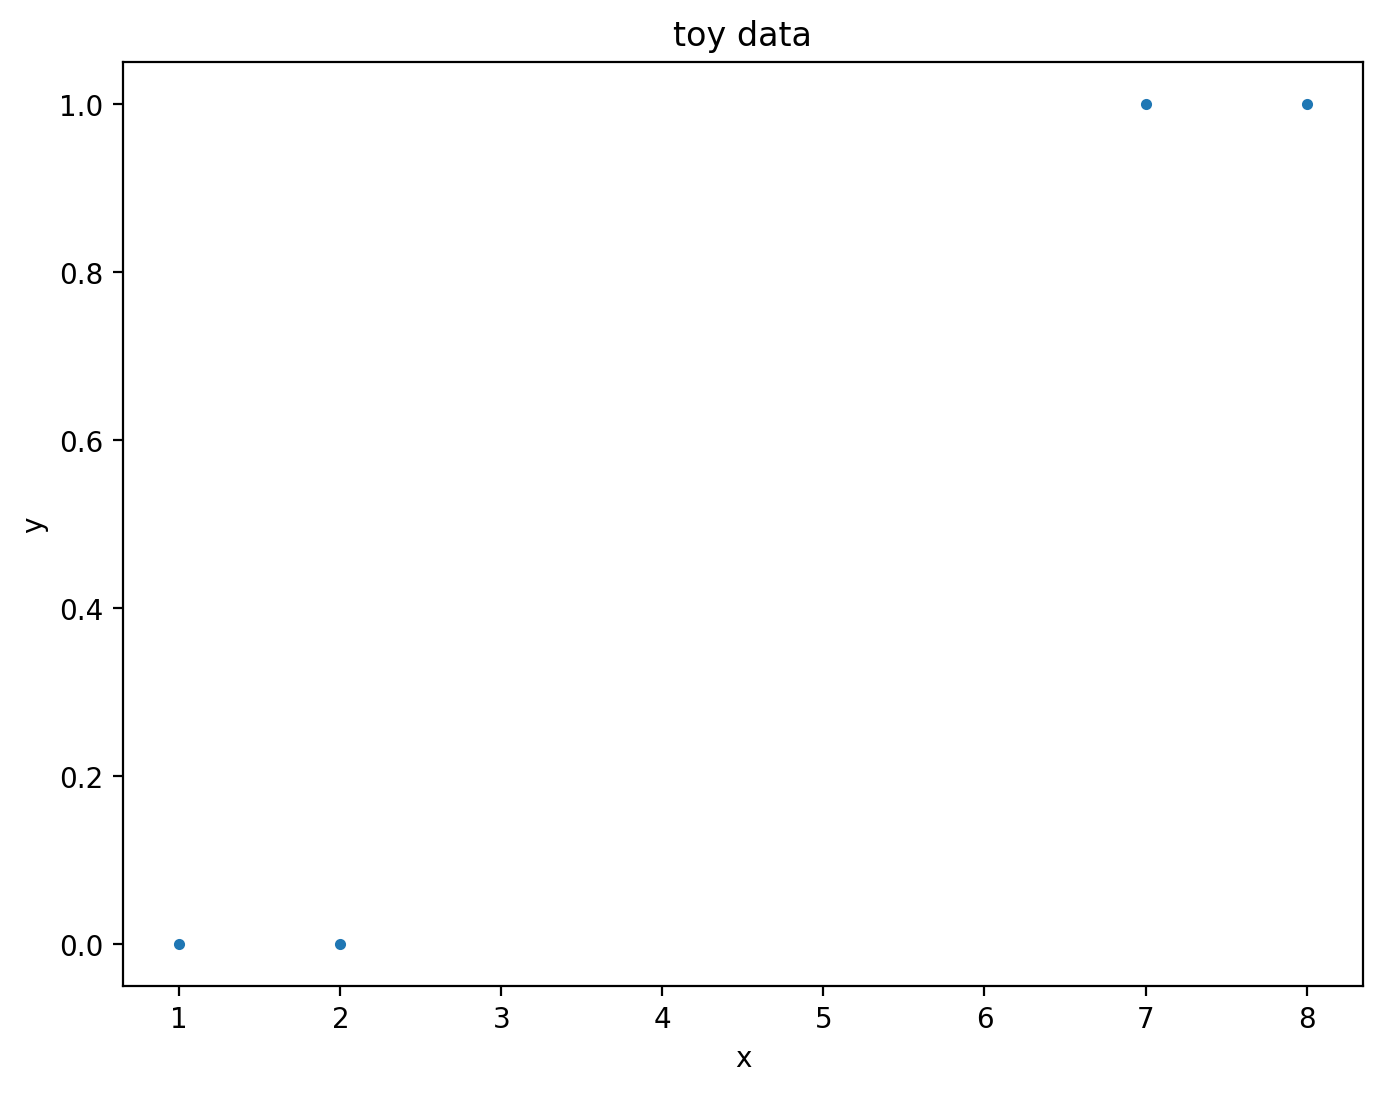

In [5]:
fig = plt.figure(figsize=(8,6))
x = [1, 2, 7, 8]
y = [0, 0, 1, 1]
plt.plot(x, y, '.')
plt.xlabel('x')
plt.ylabel('y')
plt.title('toy data')
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [7]:
clf.fit(x, y)

ValueError: Expected 2D array, got 1D array instead:
array=[1. 2. 7. 8.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [8]:
x = np.array(x).reshape(-1, 1)
print(x)

[[1]
 [2]
 [7]
 [8]]


In [9]:
clf.fit(x, y)

LogisticRegression()

In [10]:
a = clf.coef_
b = clf.intercept_
print(a, b)

[[0.85714952]] [-3.85738729]


* どのような関数が、２値分類を実現する関数として推定されたのか、描いてみる。

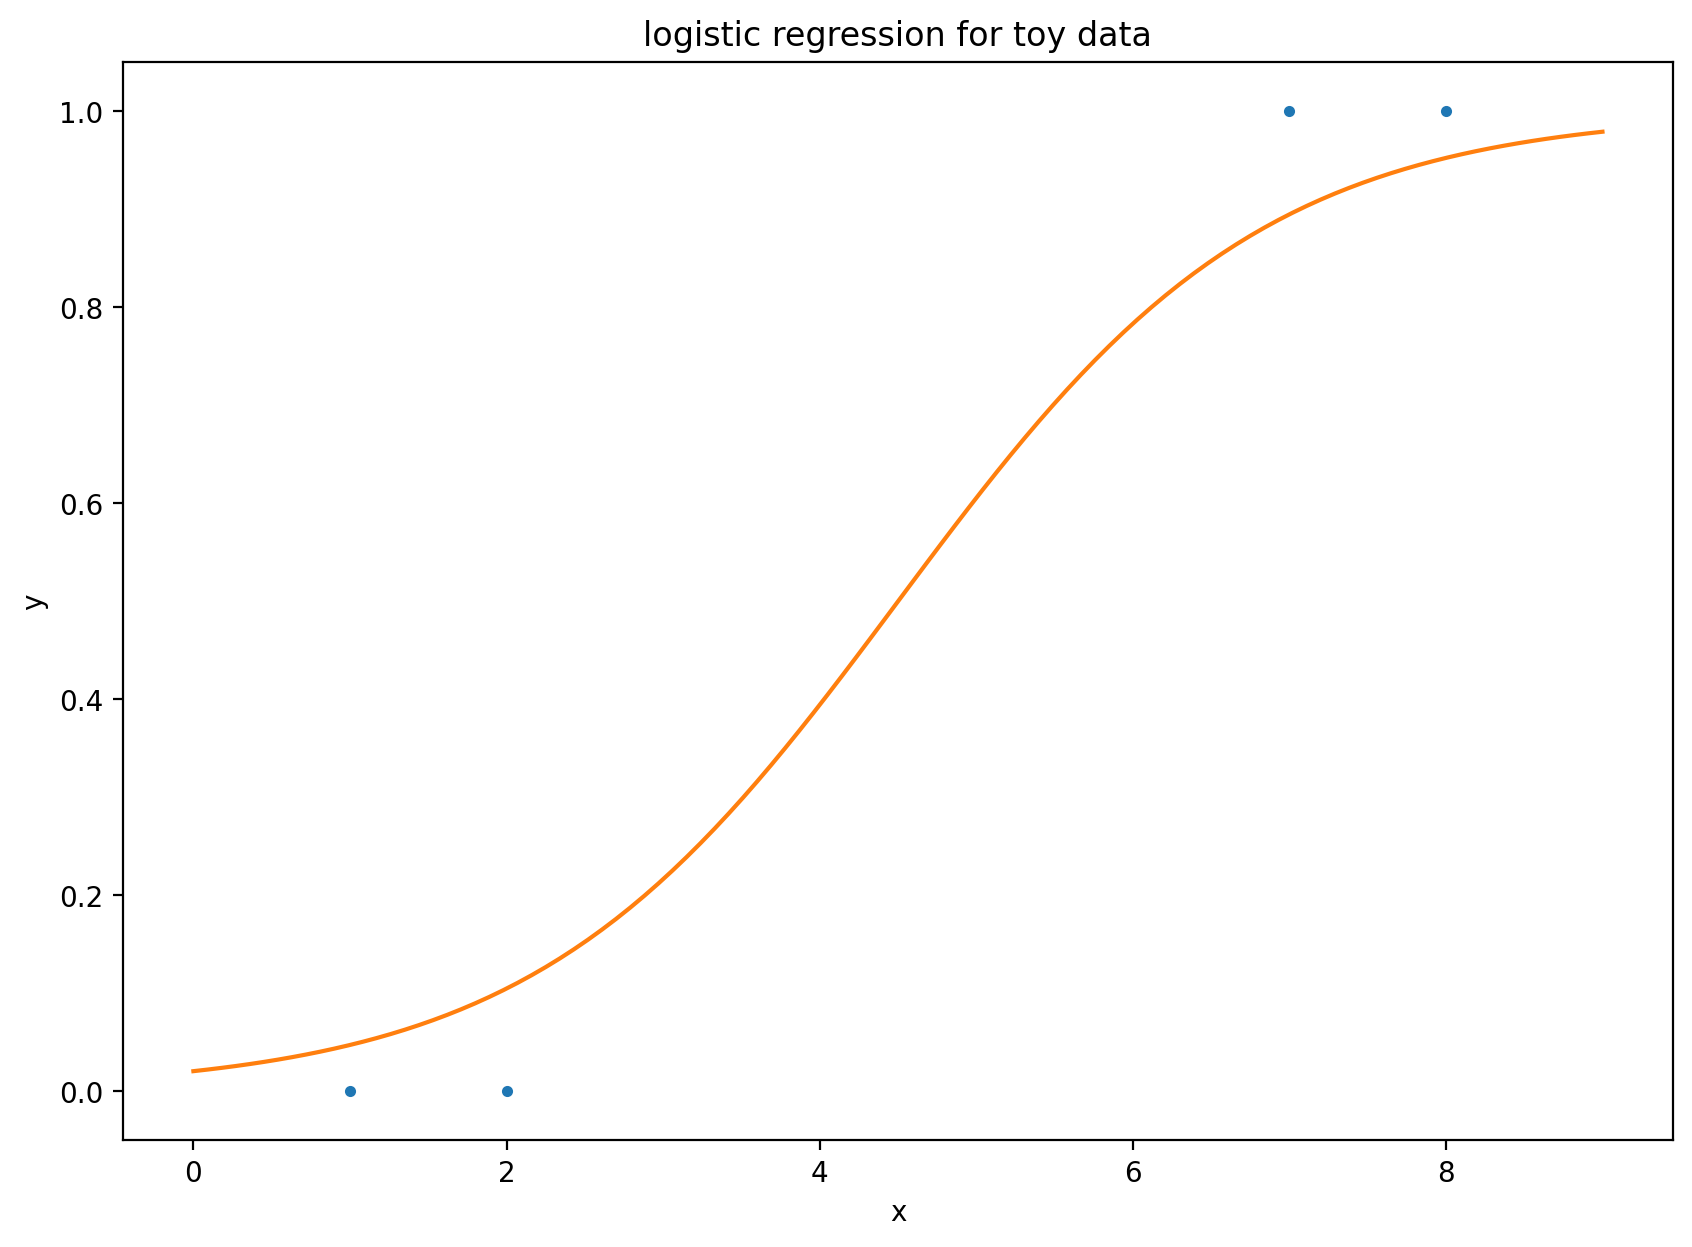

In [12]:
fig = plt.figure(figsize=(10,7))
xs = np.linspace(0,9,101)
ys = clf.predict_proba(xs.reshape(-1,1))
plt.plot(x, y, '.')
plt.plot(xs, ys[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('logistic regression for toy data')
plt.show()

# ロジスティック回帰の応用

## 手書き数字画像の分類
* digitsデータセットを使う。
* ただし、digitsデータセットは10値分類なので・・・
* 今回は、「0」かそうでないかの、2値分類問題を、ロジスティック回帰で解く。

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()

### 訓練データ/検証データ/テストデータに分割

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    digits.data,
    digits.target,
    test_size=0.2,
    random_state=42,
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
)

In [ ]:
print(X_train.shape, X_val.shape, X_test.shape)

In [ ]:
np.unique(y_train)

### ２値分類の問題へ変える
* 「0」であるものは正解ラベルを0、そうでないものは全て正解ラベルを1にする。

In [ ]:
y_train = (y_train != 0) * 1

* クラスラベルは0と1だけになっている。

In [ ]:
np.unique(y_train)

* 検証データとテストデータも同様にラベルを変更する。

In [ ]:
y_val = (y_val != 0) * 1
y_test = (y_test != 0) * 1

### ロジスティック回帰で２値分類

* ロジスティック回帰の予測の式
  * $i$番目のデータについて、以下の式で、0/1の２値ラベルを予測する。
$$ p_i = \frac{1}{1 + e^{ - ( \beta_0 + \beta_1 x_{i,1} + \cdots + \beta_d x_{i, d} ) }} $$

* 真のラベル$t_i$とのズレを表す式
$$ - \{ t_i \log p_i + ( 1 - t_i ) \log (1 - p_i) \} $$
  * この式の値を全てのデータ点にわたって足し合わせたものを最小化する。

* モデルを準備し、訓練データを渡して係数と切片を推定させる。

In [ ]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

* `max_iter`を増やしてみる

In [ ]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

In [ ]:
print(f'Accuracy: {clf.score(X_val, y_val):.4f}')

* digitsデータを0とそれ以外の2値分類にしてしまうと、問題として簡単になってしまうらしい・・・。

## MNISTデータ

### データの３分割とEDA

* scikit-learnに用意されている仕組みを利用してMNISTデータをダウンロードする。

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784')

In [ ]:
X, y = mnist.data, mnist.target

In [ ]:
print(X.shape, y.shape)

* 通常、MNISTデータは最後の10000件をテストデータとして使う。

In [ ]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

* テストデータ以外の60000件を、訓練データ50000件と検証データ10000件へ分割しておく。

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=10000,
    random_state=42,
)

In [ ]:
print(X_train.shape, X_val.shape, X_test.shape)

* 訓練データから一つの画像を眺めてみる。

In [ ]:
type(X_train)

In [ ]:
plt.imshow(X_train.values[0].reshape(28, -1), cmap=plt.cm.gray);

* 訓練データの最初の100個を可視化してみる。

In [ ]:
fig, axes = plt.subplots(10, 10)
for x, ax in zip(X_train.values, axes.ravel()):
  ax.axis('off') # 軸を消す
  ax.matshow(x.reshape(28, 28), cmap=plt.cm.gray)
plt.show()

* 問題を２値分類問題に変える。
 * 0とそれ以外の2値分類問題にしてしまう。

In [ ]:
y_train = (y_train != '0') * 1
y_val = (y_val != '0') * 1
y_test = (y_test != '0') * 1

In [ ]:
print(f'{(y_train == 0).sum()} zero digits and {(y_train == 1).sum()} non-zero digits in training set')

## ロジスティック回帰による分類の実行
* ロジスティック回帰を準備し、訓練データを渡して係数と切片を推定させる。
  * 訓練データの個数が多いので、少し時間がかかる。
  * 推定計算が収束しない場合は、`max_iter`を増やしてみる（デフォルトの設定は`max_iter=100`）。
  * `solver`（最適化アルゴリズムの設定）を`'saga'`にしているのは、こうしないと時間がかかってしまうため。

## ロジスティック回帰での正則化
* scikit-learnのロジスティック回帰では、`C`というパラメータを調整する。
* `C`は、小さいほど、正則化が強く効く＝係数をより強くゼロに近づける。
  * デフォルトの設定は`C=1.0`。
  * リッジ回帰やLassoの`alpha`とは、向きが逆であることに、注意。
* 正則化の種類は`penalty`を`'l2'`か`'l1'`に設定することでおこなう。
  * `l2`だと、係数の二乗の和を最小化する。
  * `l1`だと、係数の絶対値の和を最小化する。

In [ ]:
clf = LogisticRegression(penalty='l2', solver='saga', max_iter=500)

In [ ]:
clf.fit(X_train[::10], y_train[::10])

* 検証データで評価
  * テストデータは最終評価で一回使うだけです。

In [ ]:
print(f'Accuracy: {clf.score(X_val, y_val):.4f}')

* 推定された係数を可視化してみる。

In [ ]:
plt.imshow(clf.coef_.reshape(28,28), cmap=plt.cm.gray);

## 今回の設定をテストデータ上で評価

In [ ]:
clf = LogisticRegression(penalty='l2', solver='saga', max_iter=500)
clf.fit(X_train_val, y_train_val)
print(f'Accuracy: {clf.score(X_test, y_test):.4f}')

# 課題20260706
* 検証データでの性能がより良い性能になるよう、モデルの設定を調整して訓練データにモデルをfitさせ、検証データで評価する、ということを繰り返し行なってみよう。
* そして、このようにして見つけ出した最良の設定を使って、最後にテストデータで評価しよう。